In [18]:
import os
import datetime
import IPython
import IPython.display

import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime

# Suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Helpers

Creation of WindowGenerator Class

In [ ]:
# This version extends the TensorFlow tutorial's WindowGenerator:
# Source: https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network 
# - Supports plotting, multivariate labels, and tf.data pipelines

class WindowGenerator:
    # input_width: The number of past time steps used as input for prediction.
    # label_width: The number of future time steps the model is trained to predict.
    # shift: The number of time steps between the end of the input window and the start of the label window.
    # label_columns: A list of column names that we are trying to predict
    def __init__(self, input_width, label_width, shift, train_df, val_df, test_df, label_columns=None):
        # Raw dataframes
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Window parameters
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.label_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.label_slice]

        # Work out the label column indices.
        self.label_columns = label_columns
        if label_columns is not None:
            # nothing passed in, we are predicting ALL features
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

    # Separates Input features (past values) - input_width and Target labels (future values to predict). - label_width
    # features: 3d tensor of windowed data
    def split_window(self, features):
        # Slicing logic was defined in init, slicing happens here
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.label_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        # Slicing doesn't preserve static shape information, so set the shapes
        # manually. This way the `tf.data.Datasets` are easier to inspect.
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    def make_dataset(self, data, batch_size=32, shuffle=True):
        data = np.array(data, dtype=np.float32)
        # Keras function to convert timeseries dataframe to tf dataset

        # REVIEW
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=batch_size
        )
        # Split into inputs and labels
        return ds.map(self.split_window)
    
    # Visualizes model performance against actual values
    # model: Trained model
    # plot_col: Name of the feature/column to plot
    # max_subplots: Number of windows to display, default 3
    def plot(self, model=None, plot_col="RH", max_subplots=3):
        inputs, labels = self.example   # Batch of example windows
        plot_col_index = self.column_indices[plot_col]  # Find column index of the variable to plot

        plt.figure(figsize=(12, 6))
        for n in range(min(max_subplots, len(inputs))): # Limit number of subplots
            plt.subplot(min(max_subplots, 3), 1, n + 1)
            plt.ylabel(f"{plot_col}")
            plt.plot(self.input_indices, inputs[n, :, plot_col_index], label="Inputs", marker=".", zorder=-10)

            # Get label column index
            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, 0)
            else:
                label_col_index = plot_col_index

            # Plot actual labels
            plt.scatter(self.label_indices, labels[n, :, label_col_index], edgecolors="k", label="Labels", c="#2ca02c", s=64)
            # Plot model predictions
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index], marker="X", edgecolors="k", label="Predictions", c="#ff7f0e", s=64)

            if n == 0:
                plt.legend()

        plt.xlabel("Time Step")
        plt.tight_layout()
        plt.show()

    # Printing out all the values passed in at initialization
    def __repr__(self):
        return (
            f"Total window size: {self.total_window_size}\n"
            f"Input indices: {self.input_indices}\n"
            f"Label indices: {self.label_indices}\n"
            f"Label column(s): {self.label_columns}"
        )
    
    @property
    # Convert training set to tf dataset
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    # Convert val set to tf dataset
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)

    @property
    # Convert test set to tf dataset
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)

    @property
    def example(self):
        return next(iter(self.train))


Model Analysis Function

In [20]:
def plot_predictions(window, model, scaler, original_data, label_col="RH"):
    all_preds, all_labels = [], []

    for inputs, labels in window.test:
        preds = model.predict(inputs)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    # Concatenate all batches
    y_preds = np.concatenate(all_preds, axis=0).reshape(-1, 1)
    y_actual = np.concatenate(all_labels, axis=0).reshape(-1, 1)

    # Inverse transform
    y_preds_inv = scaler.inverse_transform(y_preds)
    y_actual_inv = scaler.inverse_transform(y_actual)

    # Match with correct timestamps from original data
    date_range = original_data.index[-len(y_preds_inv):]

    # Build results DataFrame
    results_df = pd.DataFrame({
        "date": date_range,
        "Actual RH": y_actual_inv.flatten(),
        "Predicted RH": y_preds_inv.flatten()
    })

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(results_df["date"], results_df["Actual RH"], label="Actual RH", color="blue")
    plt.plot(results_df["date"], results_df["Predicted RH"], label="Predicted RH", color="red", alpha=0.7)
    plt.title("RH Forecast vs Actual (All Batches)")
    plt.xlabel("Time")
    plt.ylabel("Relative Humidity (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Data Loading & Analysis

In [21]:
# REPLACE with actual filename
data = pd.read_csv('C:/Users/mnabh/Research - Soil Moisture Content/tx-soil-moisture/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv', 
    parse_dates=['Date'], index_col='Date')

print("\nHead:\n", data.head())
print("\nInfo:\n", data.info())
print("\nDescribe:\n", data.describe())


Head:
                       Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
Date                                                                         
2015-01-01 00:00:00  0.00  0.158   0.247   0.271   0.332  5.18  6.43  8.50   
2015-01-01 01:00:00  0.00  0.158   0.246   0.271   0.332  5.06  6.33  8.43   
2015-01-01 02:00:00  0.00  0.157   0.246   0.270   0.332  5.00  6.24  8.35   
2015-01-01 03:00:00  0.00  0.157   0.246   0.270   0.332  4.97  6.16  8.29   
2015-01-01 04:00:00  0.25  0.157   0.246   0.270   0.332  4.93  6.11  8.22   

                      T_50   Tair    RH  Windspeed  Winddirection  Srad  \
Date                                                                      
2015-01-01 00:00:00  12.78 -0.547  83.0      0.659          43.71  0.02   
2015-01-01 01:00:00  12.77 -0.440  81.6      0.670          67.43  0.20   
2015-01-01 02:00:00  12.73 -0.175  80.5      0.591          57.45  0.20   
2015-01-01 03:00:00  12.70 -0.047  80.8      0.727          77.78  0.1

Initial Data Visualization

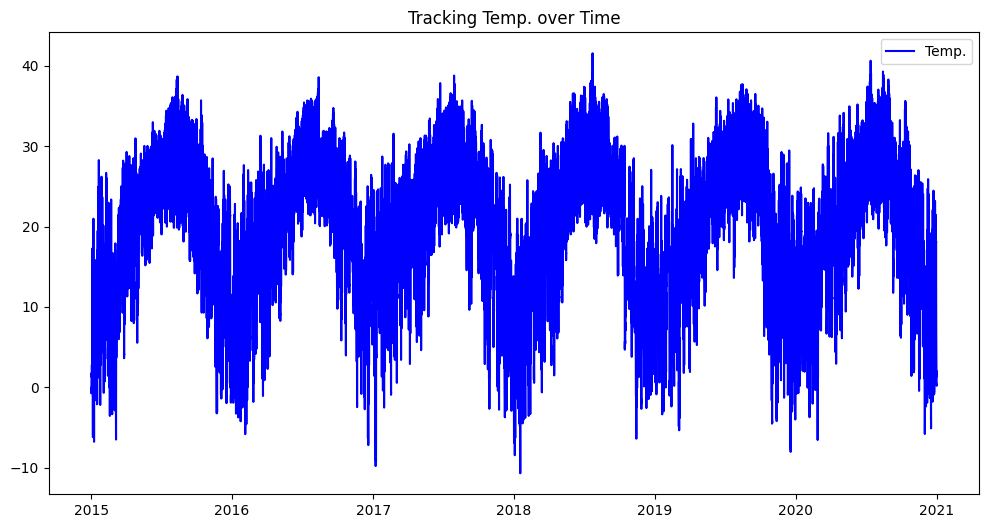

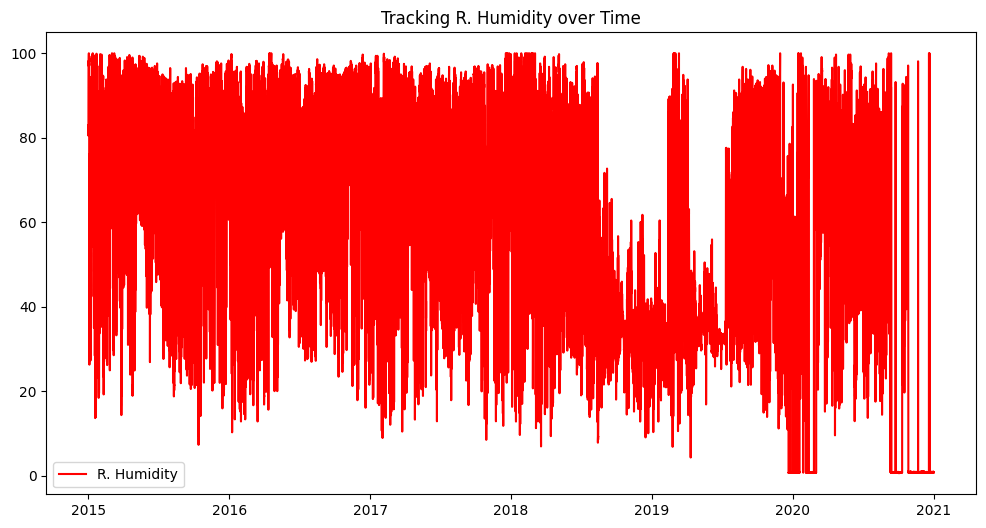

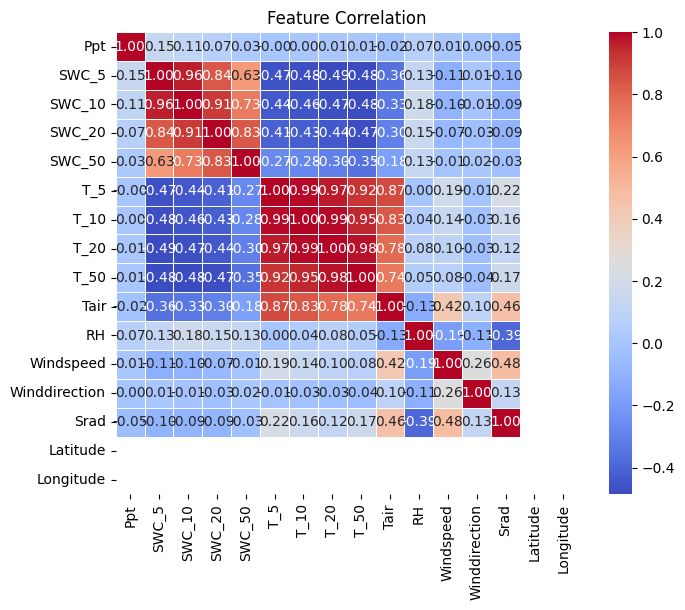

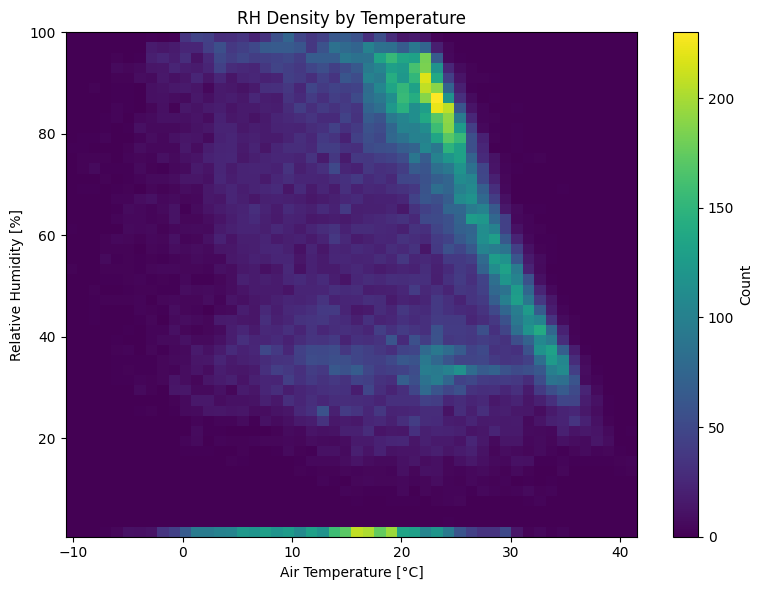

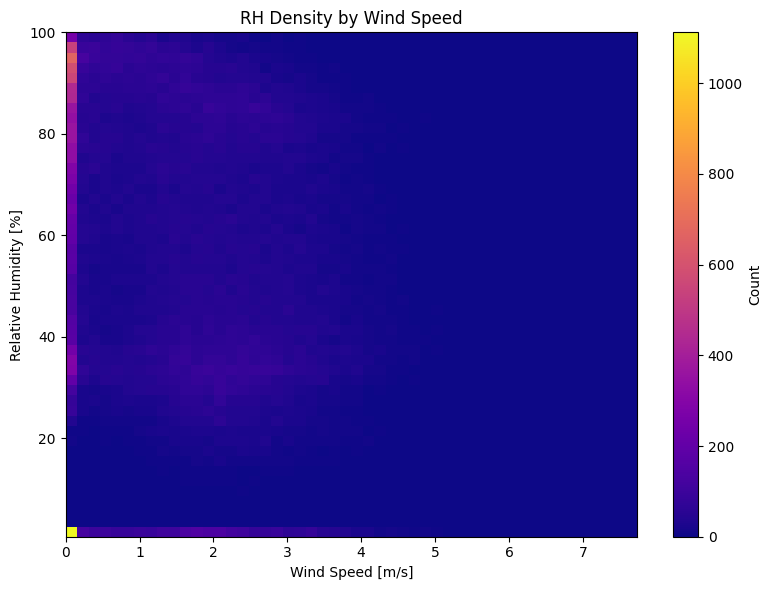

RH               1.000000
SWC_10           0.180066
SWC_20           0.153143
SWC_50           0.129578
SWC_5            0.128609
T_20             0.077247
Ppt              0.067828
T_50             0.051680
T_10             0.039486
T_5              0.001560
Winddirection   -0.114873
Tair            -0.132500
Windspeed       -0.190097
Srad            -0.388161
Latitude              NaN
Longitude             NaN
Name: RH, dtype: float64


In [25]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Tair'], label="Temp.",color="blue")
plt.title("Tracking Temp. over Time")
plt.legend ()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(data.index, data['RH'], label="R. Humidity",color="red")
plt.title("Tracking R. Humidity over Time")
plt.legend ()
plt.show()

# Check Correlations
numeric_data = data.select_dtypes(include=["float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", square=True,
    linewidths=0.5, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

plt.figure(figsize=(8, 6))
plt.hist2d(data['Tair'], data['RH'], bins=(50, 50), cmap='viridis')
plt.colorbar(label="Count")
plt.xlabel('Air Temperature [°C]')
plt.ylabel('Relative Humidity [%]')
plt.title('RH Density by Temperature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist2d(data['Windspeed'], data['RH'], bins=(50, 50), cmap='plasma')
plt.colorbar(label="Count")
plt.xlabel('Wind Speed [m/s]')
plt.ylabel('Relative Humidity [%]')
plt.title('RH Density by Wind Speed')
plt.tight_layout()
plt.show()

rh_corr = numeric_data.corr()['RH'].sort_values(ascending=False)
print(rh_corr)


# Data Preparation

Feature Engineering

In [ ]:
# Latitude and Longitude don't correlate with data trends.
# Perhaps in the future we can convert this into meaningful 
#   location data the model can understand.
# For now, we drop them and focus on other features.
data = data.drop(columns=['Latitude', 'Longitude'])

# Transform wind direction and speed into vector (Cartesian wind component)
data['Wind_X'] = data['Windspeed'] * np.cos(np.deg2rad(data['Winddirection']))
data['Wind_Y'] = data['Windspeed'] * np.sin(np.deg2rad(data['Winddirection']))
data = data.drop(columns=['Windspeed', 'Winddirection'])

# Create Time Features/ Transform date and time into more useful features
timestamp_s = data.index.map(pd.Timestamp.timestamp)
day = 24 * 60 * 60
year = (365.2425) * day

data['DaySin'] = np.sin(timestamp_s * (2 * np.pi / day))
data['DayCos'] = np.cos(timestamp_s * (2 * np.pi / day))
data['YearSin'] = np.sin(timestamp_s * (2 * np.pi / year))
data['YearCos'] = np.cos(timestamp_s * (2 * np.pi / year))

RH Fast Fourier Transform Analysis (Strong daily cycles)

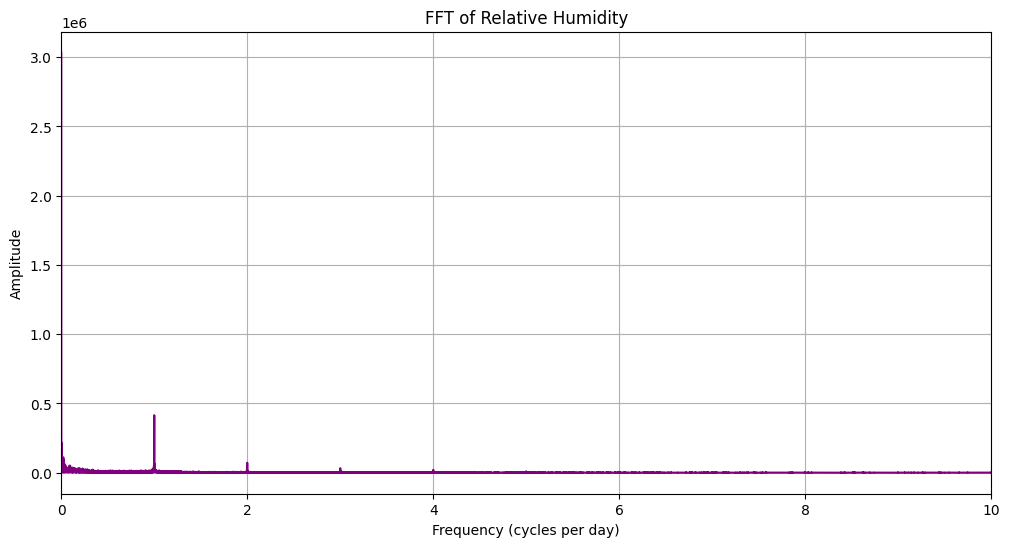

In [ ]:
rh = data['RH'].values.astype(np.float32)

# Apply FFT using TensorFlow
fft = tf.signal.rfft(rh)
f_per_dataset = np.arange(0, len(fft))
n_samples = len(rh)
f_per_day = f_per_dataset * (24 / n_samples)  # 24 data points per day

# Plot FFT magnitude spectrum
plt.figure(figsize=(12, 6))
plt.step(f_per_day, np.abs(fft), color='purple')
plt.xlabel('Frequency (cycles per day)')
plt.ylabel('Amplitude')
plt.title('FFT of Relative Humidity')
plt.xlim([0, 10])  # Limit view to lower frequencies (daily/weekly trends)
plt.grid()
plt.show()

Tair Fast Fourier Transfrom Analysis (Strong daily cycles)

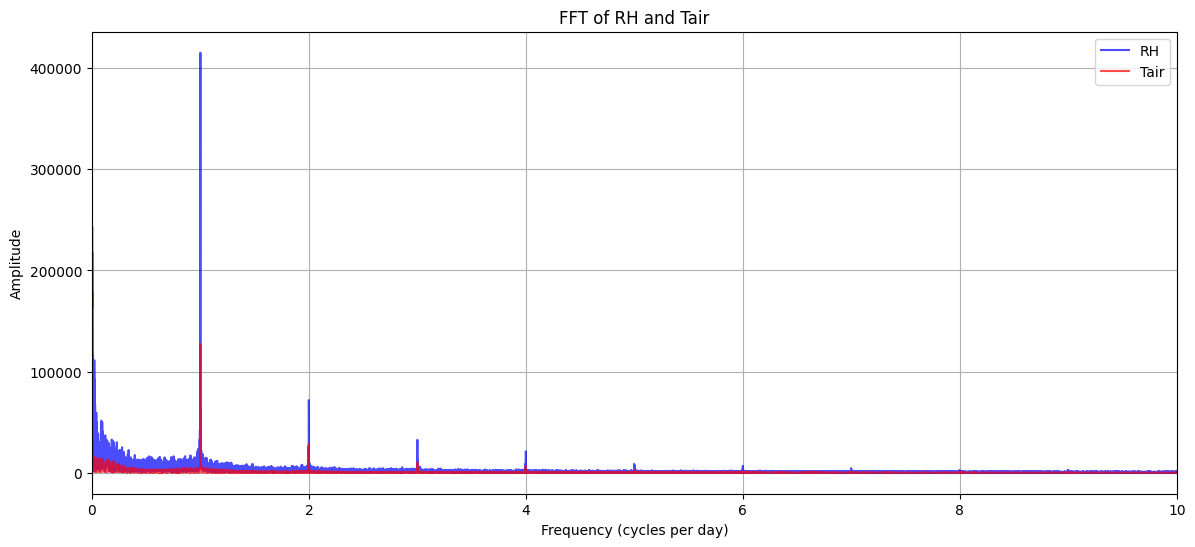

In [ ]:
rh = data['RH'].values.astype(np.float32)
tair = data['Tair'].values.astype(np.float32)

rh = rh - np.mean(rh)
tair = tair - np.mean(tair)

# Apply FFT using TensorFlow
fft_rh = tf.signal.rfft(rh)
fft_tair = tf.signal.rfft(tair)

# Frequency bins
f_per_dataset = np.arange(0, len(fft_rh))
f_per_day = f_per_dataset * (24 / len(rh))  # hourly sampling

# Plot both FFT magnitudes
plt.figure(figsize=(14, 6))
plt.step(f_per_day, np.abs(fft_rh), label="RH", color="blue", alpha=0.7)
plt.step(f_per_day, np.abs(fft_tair), label="Tair", color="red", alpha=0.7)
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Amplitude")
plt.title("FFT of RH and Tair")
plt.legend()
plt.xlim([0, 10])  # focus on daily/weekly cycles
plt.grid(True)
plt.show()

Prepare for LSTM, preprocess with StandardScaler, Divide Data

In [ ]:
# Separate out prediction feature, then use .values to convert to numpy array
data_np = data[['RH']].values

# Normalize dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_np)

training_percent = 0.7
val_percent = 0.2
test_percent = 0.1

total_len = len(scaled_data)
training_len = int(np.ceil(total_len * training_percent))
val_len = int(np.ceil(total_len * val_percent))

# Training, validation, and testing data
training_data = scaled_data[0:training_len]
val_data = scaled_data[training_len:training_len + val_len]
test_data = scaled_data[training_len + val_len:]

Sliding Window Generation

In [ ]:
# Convert to DataFrames for compatibility with WindowGenerator
train_df = pd.DataFrame(training_data, columns=["RH"])
val_df = pd.DataFrame(val_data, columns=["RH"])
test_df = pd.DataFrame(test_data, columns=["RH"])

# Create a window generator
window = WindowGenerator(
    input_width = 24,
    label_width = 1,
    shift = 1,
    train_df = train_df,
    val_df = val_df,
    test_df = test_df,
    label_columns = ["RH"]
)

Preview Dataset

In [ ]:
# Get the TensorFlow datasets
train_ds = window.train
val_ds = window.val
test_ds = window.test

print(window)

example_inputs, example_labels = window.example
print(example_inputs.shape, example_labels.shape)

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24]
Label column(s): ['RH']
(32, 24, 1) (32, 1, 1)


# RNN (LSTM) Model

Model Training

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences = False, input_shape = (window.input_width, len(window.train_df.columns))),
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(window.label_columns))
])

model.compile(
    loss = 'mae',
    optimizer = 'adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

model.fit(
    window.train,
    validation_data = window.val,
    epochs = 20
)

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - loss: 0.2528 - root_mean_squared_error: 0.3419 - val_loss: 0.1090 - val_root_mean_squared_error: 0.2193
Epoch 2/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 0.1577 - root_mean_squared_error: 0.2178 - val_loss: 0.1202 - val_root_mean_squared_error: 0.2245
Epoch 3/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 36s 31ms/step - loss: 0.1548 - root_mean_squared_error: 0.2151 - val_loss: 0.1059 - val_root_mean_squared_error: 0.2195
Epoch 4/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step - loss: 0.1536 - root_mean_squared_error: 0.2128 - val_loss: 0.1166 - val_root_mean_squared_error: 0.2221
Epoch 5/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 38s 33ms/step - loss: 0.1535 - root_mean_squared_error: 0.2133 - val_loss: 0.1134 - val_root_mean_squared_error: 0.2168
Epoch 6/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - loss: 0.1526 - root_mean_squared_error: 0.2126 - val_loss: 0.1171 - val_root_mean_squared_error: 0.2161
Epoch 7/20
1149/1149 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

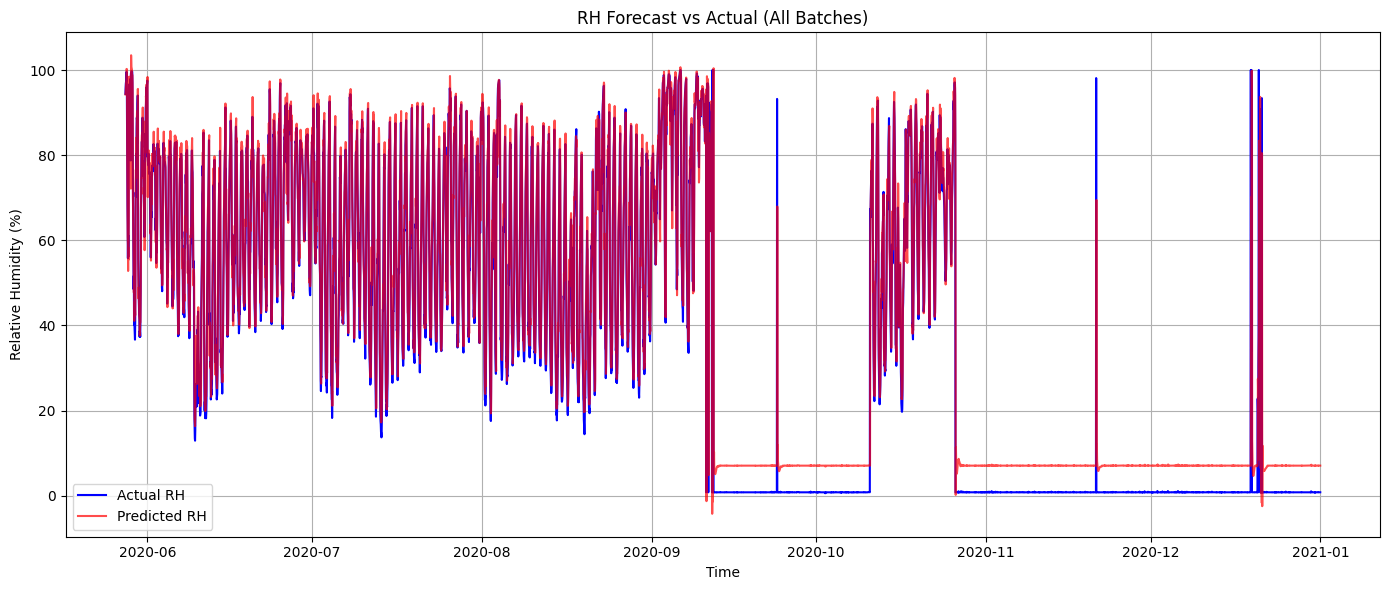

In [ ]:
plot_predictions(window, model, scaler, original_data=data)

# CNN Model

CNN Model Training

In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(
        filters = 64,
        kernel_size = 3,
        activation = 'relu',
        padding = 'same',  # preserves time dimension
        input_shape = (window.input_width, len(window.train_df.columns))
    ),
    tf.keras.layers.GlobalAveragePooling1D(),  # replaces Flatten()
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(window.label_columns))
])


cnn_model.compile(
    loss='mae',
    optimizer = 'adam',
    metrics = [tf.keras.metrics.RootMeanSquaredError()]
)

cnn = cnn_model.fit(
    window.train,
    validation_data = window.val,
    epochs = 20
)

C:\Users\mnabh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 0.5582 - root_mean_squared_error: 0.6865 - val_loss: 0.3920 - val_root_mean_squared_error: 0.5396
Epoch 2/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.3770 - root_mean_squared_error: 0.4815 - val_loss: 0.1723 - val_root_mean_squared_error: 0.3017
Epoch 3/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2214 - root_mean_squared_error: 0.2926 - val_loss: 0.1693 - val_root_mean_squared_error: 0.2884
Epoch 4/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.2113 - root_mean_squared_error: 0.2794 - val_loss: 0.1957 - val_root_mean_squared_error: 0.2919
Epoch 5/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.2038 - root_mean_squared_error: 0.2701 - val_loss: 0.1571 - val_root_mean_squared_error: 0.2783
Epoch 6/20
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1996 - root_mean_squared_error: 0.2654 - val_loss: 0.1825 - val_root_mean_squared_error: 0.3107
Epoch 7/20
1149/1149 ━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━

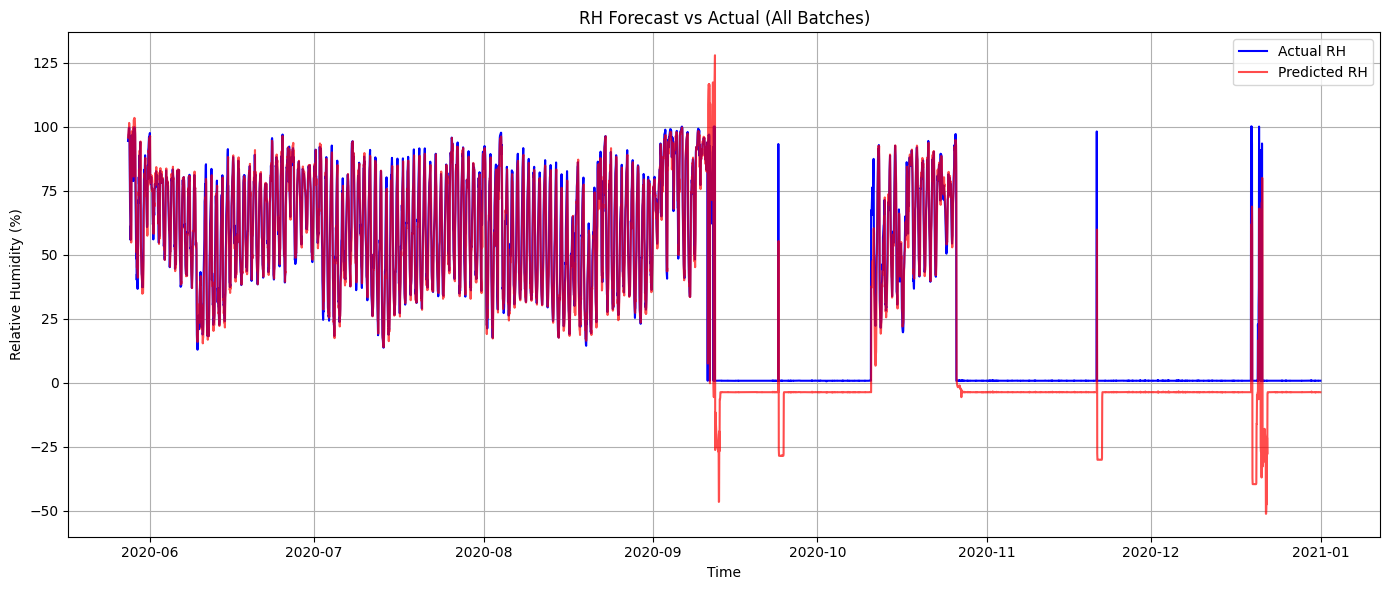

In [ ]:
plot_predictions(window, cnn_model, scaler, original_data=data)